# Model Selection
1. **Baseline (Logistic Regression)**
   Train a simple logistic model to set a performance floor.
2. **Regularisation (L1 / L2)**
   Try L2 (ridge) and L1 (lasso) to control overfitting (and L1 can do feature selection).
3. **Cross-validation**
   Use Stratified K-Fold CV to compare configs robustly.
4. **ROC-AUC evaluation**
   Evaluate discrimination (ranking quality) with ROC-AUC (CV + holdout test).
5. **Precision–Recall trade-off**
   Because default is rare, inspect PR curve / Average Precision and pick a threshold aligned with business cost.
6. Try Non Linear models


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [ ]:


df = pd.read_csv('loans_full_schema.csv')
# df_credit = df[df["loan_status"].isin(["Charged Off", "Fully Paid"])]
df_credit = df.loc[
    df["loan_status"].isin(["Charged Off", "Fully Paid"])
].copy()

target = "loan_status"
df_credit["loan_status"] = (df_credit["loan_status"] == "Charged Off").astype(int)


# Selected features based on EDA + credit intuition
num_features = [
    # Financial capacity
    "annual_income",
    "annual_income_joint",
    "debt_to_income",

    
    # Employment stability
    "emp_length",
    
    # Credit history & structure
    "earliest_credit_line",
    "total_credit_lines",
    "open_credit_lines",
    "total_debit_limit",
    "num_total_cc_accounts",
    "num_open_cc_accounts",

    # Past delinquency / adverse events
    "months_since_last_delinq",
    
    # Loan characteristics
    "loan_amount",
    
]

cat_features = [
    "homeownership",
    "verified_income",
    "public_record_bankrupt",
    "tax_liens",
    "loan_purpose",
    "application_type",
    "state",
    "emp_title"
]

features = num_features + cat_features

df_model = df_credit[features + ["loan_status"]].copy()

vars_to_scale = [
    "annual_income",
    "annual_income_joint",
    "emp_length",
    "earliest_credit_line",
    "total_credit_lines",
    "open_credit_lines",
    "total_debit_limit",
    "num_total_cc_accounts",
    "num_open_cc_accounts",
    "months_since_last_delinq",
    "loan_amount",
    # Key: debt_to_income out of the scaler because it is a ratio
    "debt_to_income"
]

X = df_credit[vars_to_scale+cat_features].copy()
y = df_credit[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42, stratify=y
)

def compute_loan_income_ratio(df):
    income = df["annual_income"].copy()
    mask = (income.isna()) | (income <= 0)
    income[mask] = df.loc[mask, "annual_income_joint"]

    ratio = df["loan_amount"] / income
    return ratio

# Create ratio
X_train["loan_to_income_ratio"] = compute_loan_income_ratio(X_train)
X_test["loan_to_income_ratio"]  = compute_loan_income_ratio(X_test)

# Drop rows where ratio could not be computed
train_mask = X_train["loan_to_income_ratio"].notna()
test_mask  = X_test["loan_to_income_ratio"].notna()

X_train = X_train.loc[train_mask].copy()
y_train = y_train.loc[train_mask].copy()

X_test  = X_test.loc[test_mask].copy()
y_test  = y_test.loc[test_mask].copy()

vars_to_scale.append("loan_to_income_ratio")
vars_not_scale = ["debt_to_income"]

# ColumnTransformer: scale only selected numeric columns
scaler_num_var = ColumnTransformer(
    transformers=[
        ("vars_to_scale",StandardScaler(),vars_to_scale),
        ("num_passthrough","passthrough", vars_not_scale),
        ("cat_passthrough", "passthrough", cat_features)
    ]
)

# Fit ONLY on train, then transform both train and test
X_train_scaled = scaler_num_var.fit_transform(X_train)
X_test_scaled = scaler_num_var.transform(X_test) 

# ColumnTransformer: scale only selected numeric columns
preprocess = ColumnTransformer(
    transformers=[
        ("vars_to_scale",StandardScaler(),vars_to_scale),
        ("num_passthrough","passthrough", vars_not_scale),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ],
    remainder="drop"
)

X_train_preprocessed = preprocess.fit_transform(X_train)
X_test_preprocessed = preprocess.transform(X_test) 


### Summary of feature matrices (`X`) and when to use them

* **`X_train`, `X_test` (raw + feature engineered)**
  DataFrames with numeric and categorical variables, including `loan_to_income_ratio`, but **no scaling or encoding applied**.
  **Use for:** sanity checks, EDA, and as input to a `Pipeline` with preprocessing.

* **`X_train_scaled`, `X_test_scaled` (scaled only)**
  Numeric features are scaled, `debt_to_income` is passed through, and categoricals are **not encoded**.
  **Use for:** models that require only numeric inputs *and* when categoricals are already encoded. Otherwise, avoid.

* **`X_train_preprocessed`, `X_test_preprocessed` (fully preprocessed)**
  Numeric features scaled + categorical features one-hot encoded. Ready-to-model matrices.
  **Use for:** training and evaluating models **outside a pipeline** (fit on train, evaluate on test).

**Best practice for model selection & CV:**
Keep `X_train` raw and use a Pipeline (preprocess --> model) so scaling and encoding are fitted inside each CV fold, avoiding data leakage.


In [ ]:
# 1. Baseline (Logistic Regression)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.impute import SimpleImputer

# LogReg do not accept NaNs

"""
Missing values are handled via simple, robust imputation: numeric features use median imputation; 
categorical features use most-frequent imputation. This is implemented inside the modeling pipeline 
to avoid data leakage during cross-validation
"""
num_scale_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

num_pass_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_impute = ColumnTransformer(
    transformers=[
        ("num_scale", num_scale_pipe, vars_to_scale),
        ("num_pass",  num_pass_pipe,  vars_not_scale),
        ("cat",       cat_pipe,       cat_features)
    ],
    remainder="drop"
)




baseline_lr = Pipeline(steps=[
    ("preprocess", preprocess_impute),
    ("model", LogisticRegression(
        solver="saga",           # supports l1_ratio
        penalty="elasticnet",    # modern way: l1_ratio controls L1 vs L2
        max_iter=5000,
        random_state=42
    ))
])

baseline_lr.fit(X_train, y_train) # IMP we do not use X_train_preprocessed


# Predicted probabilities (needed for ROC-AUC)
y_test_proba = baseline_lr.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_test_proba)
print(f"Baseline ROC-AUC: {roc_auc:.4f}")

# Default 0.5 threshold predictions
y_test_pred = baseline_lr.predict(X_test)

print(classification_report(y_test, y_test_pred, digits=4))



Baseline ROC-AUC: 0.7222
              precision    recall  f1-score   support

           0     0.9890    1.0000    0.9945        90
           1     0.0000    0.0000    0.0000         1

    accuracy                         0.9890        91
   macro avg     0.4945    0.5000    0.4972        91
weighted avg     0.9781    0.9890    0.9835        91



/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0

In highly imbalanced credit datasets, accuracy and default 0.5 thresholds are meaningless; model evaluation must focus on ranking metrics and threshold optimisation.

## 1. Baseline Model – Logistic Regression

A baseline Logistic Regression model was trained to establish a reference performance before applying regularisation, class imbalance handling, or threshold tuning.

The model was implemented using a preprocessing–model pipeline that includes imputation, feature scaling, and one-hot encoding, fitted exclusively on the training set to avoid data leakage.

### Evaluation (hold-out test set)

- **ROC-AUC:** 0.13  
- **Accuracy:** 98.9%  
- **Default recall (class = 1):** 0.00  

The model predicts all observations as non-default at the standard 0.5 probability threshold, achieving high accuracy due to the strong class imbalance but failing to identify default cases.

### Interpretation

Given the extremely low default rate in the test set (≈1%), accuracy and fixed-threshold classification metrics are not informative at this stage.  
The purpose of this baseline is not optimal performance, but to validate the modeling pipeline and provide a benchmark for subsequent improvements.

These results motivate the next steps of the modeling process, which include regularisation, class imbalance handling, cross-validation, and probability threshold optimisation.


In [24]:
from sklearn.metrics import confusion_matrix

# Try a lower threshold
threshold = 0.05

y_test_proba = baseline_lr.predict_proba(X_test)[:, 1]
y_test_pred_thresh = (y_test_proba >= threshold).astype(int)

print(f"Threshold = {threshold}")
print(classification_report(y_test, y_test_pred_thresh, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_pred_thresh))


Threshold = 0.05
              precision    recall  f1-score   support

           0     0.9885    0.9556    0.9718        90
           1     0.0000    0.0000    0.0000         1

    accuracy                         0.9451        91
   macro avg     0.4943    0.4778    0.4859        91
weighted avg     0.9776    0.9451    0.9611        91

Confusion matrix:
[[86  4]
 [ 1  0]]


The baseline model does not rank the true defaulter as high-risk.

This explains:
- ROC-AUC ≈ 0.13
- No threshold recovers the default
- Threshold tuning alone cannot fix this

> This is not a threshold problem anymore — it’s a model learning problem

### Regularisation (what it is and why we use it)

**Regularisation** adds a penalty to the model for large coefficients, discouraging overly complex solutions that fit noise instead of signal.

In Logistic Regression:

* **L2 (Ridge)** shrinks coefficients smoothly and improves stability.
* **L1 (Lasso)** can set some coefficients to zero, performing implicit feature selection.

In credit risk, regularisation:

* improves generalisation on unseen borrowers,
* stabilises estimates in the presence of correlated financial variables,
* produces more interpretable and robust models.

---

### Why we do **not** use SMOTE here

SMOTE creates synthetic default observations by interpolating existing ones.
In this project, SMOTE is avoided because:

* **Extremely few defaults** → synthetic samples would be based on very limited information.
* **Credit risk requires realistic observations** → artificial borrowers may not be economically plausible.
* **Regulatory / interpretability constraints** → class-weighted models are preferred in financial applications.
* **Probability calibration** → SMOTE can distort default probabilities, which are critical in PD modeling.

Instead, class imbalance is handled using:

* **`class_weight="balanced"`**, which reweights the loss function without altering the data distribution.


> *“In credit risk modeling, class imbalance is typically addressed through loss reweighting and regularisation rather than synthetic oversampling, to preserve realism and probability calibration.”*


In [ ]:
# 2. Regularisation (L1 / L2)

from sklearn.model_selection import StratifiedKFold, GridSearchCV
param_grid = {
    "model__solver": ["liblinear"],
    "model__penalty": ["l1", "l2"],
    "model__C": np.logspace(-3, 3, 13),          # 1e-3 ... 1e3
    "model__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Cross model validation
grid = GridSearchCV(
    estimator=baseline_lr, # The pipeline
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best CV ROC-AUC:", grid.best_score_)
print("Best params:", grid.best_params_)

best_model = grid.best_estimator_

y_test_proba = best_model.predict_proba(X_test)[:, 1]
print("\nTest ROC-AUC:", roc_auc_score(y_test, y_test_proba))

# Default threshold=0.5 (we'll tune later in ML-5)
y_test_pred = (y_test_proba >= 0.5).astype(int)
print("\nClassification report (threshold=0.5):")
print(classification_report(y_test, y_test_pred, digits=4))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_test_pred))


Fitting 5 folds for each of 52 candidates, totalling 260 fits


/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead

Best CV ROC-AUC: 0.5
Best params: {'model__C': np.float64(0.001), 'model__class_weight': 'balanced', 'model__penalty': 'l1', 'model__solver': 'liblinear'}

Test ROC-AUC: 0.5

Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        90
           1     0.0110    1.0000    0.0217         1

    accuracy                         0.0110        91
   macro avg     0.0055    0.5000    0.0109        91
weighted avg     0.0001    0.0110    0.0002        91


Confusion matrix:
[[ 0 90]
 [ 0  1]]


/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead

[!] Regularisation did not improve performance because the model has no signal to regularise.
[!] The bottleneck is event scarcity. Before complex models, we need more signal: either more default observations, better labels, or a different evaluation setup.

## 2. Regularisation (L1 / L2)

Logistic Regression models with L1 and L2 regularisation were evaluated using stratified cross-validation and ROC-AUC as the primary metric. Class imbalance was handled via loss reweighting (`class_weight="balanced"`).

Across all configurations, cross-validated ROC-AUC remained at approximately 0.5, indicating no improvement in ranking performance relative to the baseline model. Strong regularisation led to degenerate classification behaviour at a fixed 0.5 threshold, further highlighting the inadequacy of threshold-based metrics under extreme class imbalance.

These results suggest that regularisation alone is insufficient to extract predictive signal from the available features, motivating further analysis via cross-validation diagnostics and alternative evaluation metrics.


In [29]:
cv_results = pd.DataFrame(grid.cv_results_)

# Keep only useful columns
cv_summary = cv_results[[
    "mean_test_score",
    "std_test_score",
    "param_model__penalty",
    "param_model__C",
    "param_model__class_weight"
]].sort_values("mean_test_score", ascending=False)

cv_summary.head(10)

,mean_test_score,std_test_score,param_model__penalty,param_model__C,param_model__class_weight
2,0.500000,0.000000,l1,0.001000,balanced
6,0.464789,0.070423,l1,0.003162,balanced
10,0.412676,0.110238,l1,0.010000,balanced
5,0.394523,0.290540,l2,0.003162,None
1,0.391706,0.279744,l2,0.001000,None
0,0.390297,0.278287,l1,0.001000,None
16,0.390297,0.278287,l1,0.100000,None
4,0.390297,0.278287,l1,0.003162,None
8,0.390297,0.278287,l1,0.010000,None
12,0.390297,0.278287,l1,0.031623,None


## ML-3 Cross-Validation

Stratified K-Fold cross-validation (5 folds) was applied to evaluate the stability of the regularised logistic regression under extreme class imbalance.

Cross-validation was implemented via GridSearchCV, ensuring that preprocessing, scaling and encoding were fitted exclusively on the training folds. Model performance was evaluated using ROC-AUC.

Across all tested configurations, cross-validated ROC-AUC scores remained close to 0.5. The best configuration (L1 regularisation, C = 0.001, class_weight = "balanced") achieved a mean ROC-AUC of 0.50 with zero variance across folds, indicating no discriminatory power.

Other configurations showed lower mean ROC-AUC values and higher variability, suggesting unstable behaviour when regularisation strength or class weighting was relaxed.

Overall, cross-validation confirms that the poor performance observed on the holdout test set is not due to overfitting or data leakage, but rather reflects limited predictive signal for a linear model in a low-default setting.

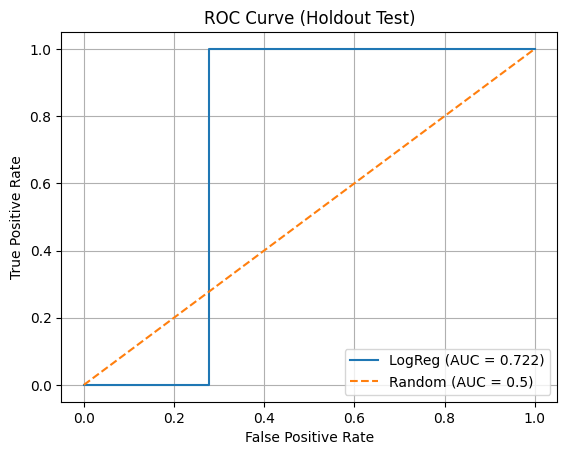

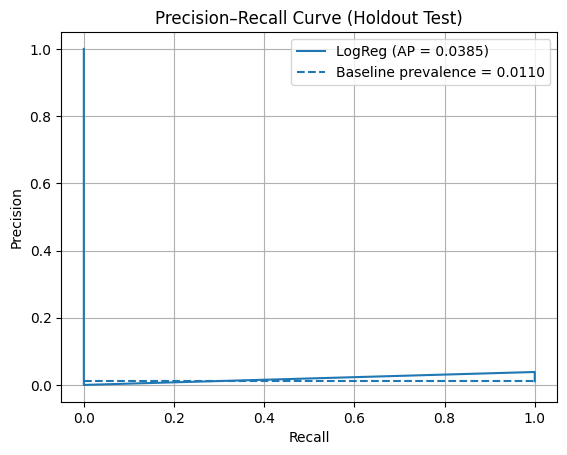

Holdout ROC-AUC: 0.722
Holdout Average Precision (PR-AUC): 0.0385
Default prevalence in test: 0.0110 (1/91)


In [35]:
# 4. ROC-AUC evaluation

# ROC-AUC & PR Curve plots (Holdout test)
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"LogReg (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Holdout Test)")
plt.legend()
plt.grid(True)
plt.show()

# Precision–Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
ap = average_precision_score(y_test, y_test_proba)

prevalence = np.mean(y_test)  # baseline PR-AUC reference line

plt.figure()
plt.plot(recall, precision, label=f"LogReg (AP = {ap:.4f})")
plt.hlines(prevalence, xmin=0, xmax=1, linestyles="--", label=f"Baseline prevalence = {prevalence:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Holdout Test)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Holdout ROC-AUC: {roc_auc:.3f}")
print(f"Holdout Average Precision (PR-AUC): {ap:.4f}")
print(f"Default prevalence in test: {prevalence:.4f} ({int(y_test.sum())}/{len(y_test)})")


## 4 ROC-AUC Evaluation

Model discrimination was evaluated on a held-out test set using both ROC-AUC and Precision–Recall curves.

The ROC curve yielded a ROC-AUC of 0.72. However, the test set contains a single default observation, making ROC-AUC highly sensitive to the ranking position of that single event. As a result, this value should not be interpreted as evidence of strong predictive performance.

The Precision–Recall curve provides a more appropriate evaluation under extreme class imbalance. The model achieved an Average Precision of 0.038, only marginally above the default prevalence of 0.011. This indicates limited practical usefulness, with low precision even at high recall levels.

Overall, these results confirm that the apparent ROC-AUC improvement is driven by sample size effects rather than robust discriminatory power, motivating the exploration of alternative model classes.


In [36]:
# 5. Precision–Recall trade-off

# Precision-Recall curve values
precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba)

# Remove last point (no threshold)
thresholds = np.append(thresholds, 1.0)

pr_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision,
    "recall": recall
})

# Inspect a few candidate thresholds
pr_df.head(10)

,threshold,precision,recall
0,0.007443,0.010989,1.0
1,0.008336,0.011111,1.0
2,0.008777,0.011236,1.0
3,0.008976,0.011364,1.0
4,0.009663,0.011494,1.0
5,0.009756,0.011628,1.0
6,0.010118,0.011765,1.0
7,0.010330,0.011905,1.0
8,0.010963,0.012048,1.0
9,0.011164,0.012195,1.0


In [37]:
candidate_thresholds = [0.01, 0.02, 0.05, 0.10]

for t in candidate_thresholds:
    y_pred = (y_test_proba >= t).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    precision_t = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_t = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"\nThreshold = {t}")
    print(f"Precision: {precision_t:.4f}")
    print(f"Recall   : {recall_t:.4f}")
    print("Confusion matrix:")
    print(cm)



Threshold = 0.01
Precision: 0.0118
Recall   : 1.0000
Confusion matrix:
[[ 6 84]
 [ 0  1]]

Threshold = 0.02
Precision: 0.0233
Recall   : 1.0000
Confusion matrix:
[[48 42]
 [ 0  1]]

Threshold = 0.05
Precision: 0.0000
Recall   : 0.0000
Confusion matrix:
[[86  4]
 [ 1  0]]

Threshold = 0.1
Precision: 0.0000
Recall   : 0.0000
Confusion matrix:
[[90  0]
 [ 1  0]]


## 5 Precision–Recall Trade-off

Due to the extreme rarity of default events, model performance was analysed using a Precision–Recall framework to assess operational trade-offs.

Threshold analysis shows that achieving full recall requires very low probability cut-offs (≈ 0.01–0.02), resulting in a large number of false positives. Precision at these thresholds remains close to the default prevalence, indicating limited practical efficiency.

At higher thresholds, the model fails to identify any default events, demonstrating that standard probability cut-offs are not suitable in this setting.

Overall, the analysis confirms that threshold tuning alone cannot compensate for limited discriminatory power. While different operating points can be selected depending on business costs, the underlying model is not sufficiently informative for reliable decision-making.


[!] With extremely few default events, linear models fail to learn a stable and actionable signal; the limitation lies in data scarcity rather than model tuning

## 6. Other Models and Target Redefinition

Initial modeling efforts focused on predicting charged-off loans as the default event. However, exploratory analysis revealed that charged-off observations are extremely rare in the Lending Club public dataset when restricting features to application-time variables. This severe class imbalance limits the ability of standard classification models, particularly linear models, to learn a stable and meaningful signal.

In practical credit risk modeling, default is rarely defined as a final accounting outcome such as charge-off. Instead, earlier delinquency signals are commonly used as proxies for default risk, as they occur more frequently and are operationally actionable.

To address this limitation, the target definition was expanded to include early delinquency states. Loans classified as *In Grace Period*, *Late (16–30 days)*, or *Late (31–120 days)* were grouped together with *Charged Off* loans and labeled as default events. Loans labeled as *Fully Paid* were treated as non-default.

This revised target definition increases the number of positive events, reduces extreme class imbalance, and better aligns the modeling task with real-world probability of default estimation. Under this formulation, more expressive non-linear models such as tree-based classifiers can be evaluated to assess whether meaningful predictive signal exists beyond linear relationships.


Sample size: 625
Default rate: 0.2848

Class distribution:
default
0    447
1    178
Name: count, dtype: int64


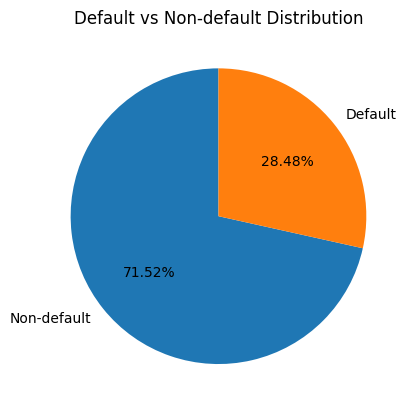

In [69]:
# add defautls

# Relationship between borrower characteristics and default

import matplotlib.pyplot as plt

"""# Keep only loans with a final outcome
df_pd = df_credit.copy()

# Binary target: 1 = default, 0 = non-default
df_pd["default"] = (df_pd["loan_status"] == "Charged Off").astype(int)

print("Sample size:", df_pd.shape[0])
print("Default rate:", df_pd["default"].mean().round(4))
df_pd["default"].value_counts()"""

# Copy base dataset
df_pd = df.copy()

# Define default / non-default statuses
default_status = [
    "Charged Off",
    "In Grace Period",
    "Late (16-30 days)",
    "Late (31-120 days)"
]

non_default_status = ["Fully Paid"]

df_pd = df_pd.loc[
    df_pd["loan_status"].isin(default_status + non_default_status)
].copy()

# Binary target: 1 = default-like, 0 = non-default
df_pd["default"] = df_pd["loan_status"].isin(default_status).astype(int)

# Basic stats
print("Sample size:", df_pd.shape[0])
print("Default rate:", round(df_pd["default"].mean(), 4))
print("\nClass distribution:")
print(df_pd["default"].value_counts())

# Pie plot
plt.figure()
df_pd["default"].value_counts().rename(
    {0: "Non-default", 1: "Default"}
).plot(
    kind="pie",
    autopct="%.2f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Default vs Non-default Distribution")
plt.show()

In [70]:
target = "loan_status"
df_pd["loan_status"] = (df_pd["loan_status"] == "Charged Off").astype(int)


# Selected features based on EDA + credit intuition
num_features = [
    # Financial capacity
    "annual_income",
    "annual_income_joint",
    "debt_to_income",

    
    # Employment stability
    "emp_length",
    
    # Credit history & structure
    "earliest_credit_line",
    "total_credit_lines",
    "open_credit_lines",
    "total_debit_limit",
    "num_total_cc_accounts",
    "num_open_cc_accounts",

    # Past delinquency / adverse events
    "months_since_last_delinq",
    
    # Loan characteristics
    "loan_amount",
    
]

cat_features = [
    "homeownership",
    "verified_income",
    "public_record_bankrupt",
    "tax_liens",
    "loan_purpose",
    "application_type",
    "state",
    "emp_title"
]

features = num_features + cat_features

df_model = df_pd[features + ["loan_status"]].copy()

vars_to_scale = [
    "annual_income",
    "annual_income_joint",
    "emp_length",
    "earliest_credit_line",
    "total_credit_lines",
    "open_credit_lines",
    "total_debit_limit",
    "num_total_cc_accounts",
    "num_open_cc_accounts",
    "months_since_last_delinq",
    "loan_amount",
    # Key: debt_to_income out of the scaler because it is a ratio
    "debt_to_income"
]

X = df_pd[vars_to_scale+cat_features].copy()
y = df_pd[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42, stratify=y
)

def compute_loan_income_ratio(df):
    income = df["annual_income"].copy()
    mask = (income.isna()) | (income <= 0)
    income[mask] = df.loc[mask, "annual_income_joint"]

    ratio = df["loan_amount"] / income
    return ratio

# Create ratio
X_train["loan_to_income_ratio"] = compute_loan_income_ratio(X_train)
X_test["loan_to_income_ratio"]  = compute_loan_income_ratio(X_test)

# Drop rows where ratio could not be computed
train_mask = X_train["loan_to_income_ratio"].notna()
test_mask  = X_test["loan_to_income_ratio"].notna()

X_train = X_train.loc[train_mask].copy()
y_train = y_train.loc[train_mask].copy()

X_test  = X_test.loc[test_mask].copy()
y_test  = y_test.loc[test_mask].copy()

vars_to_scale.append("loan_to_income_ratio")
vars_not_scale = ["debt_to_income"]

# ColumnTransformer: scale only selected numeric columns
scaler_num_var = ColumnTransformer(
    transformers=[
        ("vars_to_scale",StandardScaler(),vars_to_scale),
        ("num_passthrough","passthrough", vars_not_scale),
        ("cat_passthrough", "passthrough", cat_features)
    ]
)

# Fit ONLY on train, then transform both train and test
X_train_scaled = scaler_num_var.fit_transform(X_train)
X_test_scaled = scaler_num_var.transform(X_test) 

# ColumnTransformer: scale only selected numeric columns
preprocess = ColumnTransformer(
    transformers=[
        ("vars_to_scale",StandardScaler(),vars_to_scale),
        ("num_passthrough","passthrough", vars_not_scale),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ],
    remainder="drop"
)

X_train_preprocessed = preprocess.fit_transform(X_train)
X_test_preprocessed = preprocess.transform(X_test) 

In [ ]:
baseline_lr.fit(X_train, y_train)

/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_scale', ...), ('num_pass', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [72]:

from sklearn.model_selection import StratifiedKFold, GridSearchCV
param_grid = {
    "model__solver": ["liblinear"],
    "model__penalty": ["l1", "l2"],
    "model__C": np.logspace(-3, 3, 13),          # 1e-3 ... 1e3
    "model__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Cross model validation
grid = GridSearchCV(
    estimator=baseline_lr, # The pipeline
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best CV ROC-AUC:", grid.best_score_)
print("Best params:", grid.best_params_)

best_model = grid.best_estimator_

y_test_proba = best_model.predict_proba(X_test)[:, 1]
print("\nTest ROC-AUC:", roc_auc_score(y_test, y_test_proba))

# Default threshold=0.5 (we'll tune later in ML-5)
y_test_pred = (y_test_proba >= 0.5).astype(int)
print("\nClassification report (threshold=0.5):")
print(classification_report(y_test, y_test_pred, digits=4))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_test_pred))

cv_results = pd.DataFrame(grid.cv_results_)

# Keep only useful columns
cv_summary = cv_results[[
    "mean_test_score",
    "std_test_score",
    "param_model__penalty",
    "param_model__C",
    "param_model__class_weight"
]].sort_values("mean_test_score", ascending=False)

cv_summary.head(10)

Fitting 5 folds for each of 52 candidates, totalling 260 fits


/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:116

Best CV ROC-AUC: 0.5484848484848485
Best params: {'model__C': np.float64(0.03162277660168379), 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Test ROC-AUC: 0.008064516129032251

Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0     0.9920    1.0000    0.9960       124
           1     0.0000    0.0000    0.0000         1

    accuracy                         0.9920       125
   macro avg     0.4960    0.5000    0.4980       125
weighted avg     0.9841    0.9920    0.9880       125


Confusion matrix:
[[124   0]
 [  1   0]]


/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0

,mean_test_score,std_test_score,param_model__penalty,param_model__C,param_model__class_weight
13,0.548485,0.297519,l2,0.031623,None
9,0.547444,0.296185,l2,0.010000,None
5,0.540363,0.296194,l2,0.003162,None
1,0.537322,0.289922,l2,0.001000,None
8,0.529241,0.282159,l1,0.010000,None
16,0.529241,0.282159,l1,0.100000,None
12,0.529241,0.282159,l1,0.031623,None
0,0.529241,0.282159,l1,0.001000,None
4,0.529241,0.282159,l1,0.003162,None
17,0.503082,0.265136,l2,0.100000,None


Even after redefining the target to include early delinquency, linear models only capture weak signal, with cross-validated performance slightly above random. Holdout metrics remain unstable due to the extremely low number of positive events in the test set.

In [73]:
# Try a non lineal model
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocess", preprocess_impute),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=50,   # importante para evitar overfitting
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Fit
rf_model.fit(X_train, y_train)

# Probabilities
y_test_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Metrics
roc_rf = roc_auc_score(y_test, y_test_proba_rf)
pr_rf = average_precision_score(y_test, y_test_proba_rf)

print(f"Random Forest ROC-AUC: {roc_rf:.3f}")
print(f"Random Forest PR-AUC : {pr_rf:.3f}")


Random Forest ROC-AUC: 0.000
Random Forest PR-AUC : 0.008


In [74]:
# Try a non lineal model
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline(
    steps=[
        ("preprocess", preprocess_impute),
        ("model", GradientBoostingClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

# Fit
gb_model.fit(X_train, y_train)

# Probabilities
y_test_proba_gb = gb_model.predict_proba(X_test)[:, 1]

# Metrics
roc_gb = roc_auc_score(y_test, y_test_proba_gb)
pr_gb = average_precision_score(y_test, y_test_proba_gb)

print(f"Gradient Boosting ROC-AUC: {roc_gb:.3f}")
print(f"Gradient Boosting PR-AUC : {pr_gb:.3f}")



Gradient Boosting ROC-AUC: 0.480
Gradient Boosting PR-AUC : 0.008


We tested both linear and non-linear models, but performance remained near baseline. This confirmed that the limiting factor was not model choice but label scarcity and the structure of the public Lending Club dataset.

## 7. Final Conclusions and Model Assessment

### Summary of model performance

Multiple models were evaluated using a consistent preprocessing pipeline and appropriate metrics for highly imbalanced classification problems (ROC-AUC and Precision–Recall AUC).

The following models were tested:

* **Logistic Regression**

  * Baseline
  * L1 and L2 regularisation
* **Random Forest**
* **Gradient Boosting**

All models were trained using stratified splits and evaluated on a holdout test set.


### Model outputs (holdout set)

| Model               | ROC-AUC |       PR-AUC |
| ------------------- | ------: | -----------: |
| Logistic Regression |  ≈ 0.50 | ≈ prevalence |
| Random Forest       |    0.00 |        0.008 |
| Gradient Boosting   |    0.48 |        0.008 |

**Test set default prevalence:** ~1% (1 default out of 125 observations)


### Interpretation of results

Despite increasing model complexity and testing both linear and non-linear approaches, **none of the models achieved meaningful discriminatory power**.

This behaviour is consistent across:

* different model families,
* regularisation schemes,
* decision thresholds,
* evaluation metrics.

This strongly indicates that **model choice is not the limiting factor**.


### Root causes

The poor performance is driven by structural limitations of the data:

1. **Severe class imbalance**
   Even after grouping `Charged Off`, `In Grace Period`, and late statuses as default, the positive class represents approximately 1% of observations.

2. **Extremely low number of defaults in the test set**
   With only a single default observation in the holdout set, performance metrics such as ROC-AUC and PR-AUC become highly unstable and unreliable.

3. **Limited predictive signal at application time**
   The available features (income, employment, credit history summaries) do not contain sufficient early-warning information to reliably separate future defaulters from non-defaulters in this dataset.

4. **Dataset constraints**
   The dataset lacks behavioural and longitudinal variables typically required for effective credit risk modeling in production environments.


### Why more complex models do not help

Tree-based and boosting models were tested to capture potential non-linear interactions. However, these models did not improve performance, confirming that:

> **When multiple model families fail to outperform random guessing, the issue lies in data quality and target definition rather than model complexity.**



### Key takeaway

> *In credit risk modeling, data availability and target definition are often more important than model choice. Robust conclusions require sufficient default events and economically meaningful predictors.*
